In [ ]:
import os
import zipfile
import xarray as xr
from pathlib import Path

import dask.diagnostics
import ngff_zarr
import numpy as np
import dask.array as da
import tifffile
from multiview_stitcher import spatial_image_utils as si_utils
from multiview_stitcher import (
    fusion,
        io,
            msi_utils,
                vis_utils,
                    ngff_utils,
                        param_utils,
                            registration,
                            )
                            from tqdm import tqdm

Arranging the tiles on the grid

In [6]:
import h5py
from pathlib import Path

# --------------------------------------------------
# Folder path
folder_path = r"Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\Full dataset"

folder = Path(folder_path)
ims_files = sorted(folder.glob("*.ims"))

positions = []

# --------------------------------------------------
# Loop files
for file in ims_files:

    with h5py.File(file, "r") as f:
        img = f["DataSetInfo/Image"].attrs

        # Decode helper inline
        xmin = float(b"".join(img["ExtMin0"]).decode())
        xmax = float(b"".join(img["ExtMax0"]).decode())

        ymin = float(b"".join(img["ExtMin1"]).decode())
        ymax = float(b"".join(img["ExtMax1"]).decode())

        zmin = float(b"".join(img["ExtMin2"]).decode())
        zmax = float(b"".join(img["ExtMax2"]).decode())

        # # Center position
        # x = (xmin + xmax) / 2
        # y = (ymin + ymax) / 2
        # z = (zmin + zmax) / 2

        positions.append({
            'xmin': xmin,
            'xmax': xmax,
            'ymin': ymin,
            'ymax': ymax,
            'zmin': zmin,
            'zmax': zmax
        })

# Convert to translations

ref = positions[0]

# translations = []

# for pos in positions:
#     translations.append({
#         "xmin": pos["xmin"] - ref["xmin"],
#         "xmax": pos["xmax"] - ref["xmax"],
#         "ymin": pos["ymin"] - ref["ymin"],
#         "ymax": pos["ymax"] - ref["ymax"],
#         "zmin": pos["zmin"] - ref["zmin"],
#         "zmax": pos["zmax"] - ref["zmax"],
#     })

translations = [
    {
        "x": pos["xmin"] - ref["xmin"],
        "y": pos["ymin"] - ref["ymin"],
        "z": pos["zmin"] - ref["zmin"],
    }
    for pos in positions
]

# --------------------------------------------------
# Print result
for i, pos in enumerate(translations, 1):
    print(f"{i}: X={pos['x']:.3f}, Y={pos['y']:.3f}, Z={pos['z']:.3f}")

z_spacing, y_pixel_size, x_pixel_size = 1.3636364, 0.3045934, 0.3045934

scale = {
'z': z_spacing,
'y': y_pixel_size,
'x': x_pixel_size
}

1: X=0.000, Y=0.000, Z=0.000
2: X=0.000, Y=-546.070, Z=-0.100
3: X=559.230, Y=-546.070, Z=-0.800
4: X=559.230, Y=0.000, Z=-0.800
5: X=559.230, Y=546.080, Z=-0.700
6: X=1118.460, Y=1092.150, Z=-1.500
7: X=1118.460, Y=546.080, Z=-1.500
8: X=1118.460, Y=0.000, Z=-1.600
9: X=1118.460, Y=-546.070, Z=-1.600
10: X=1677.690, Y=-546.070, Z=-2.400
11: X=1677.690, Y=0.000, Z=-2.400
12: X=1677.690, Y=546.080, Z=-2.300
13: X=1677.690, Y=1092.150, Z=-2.300
14: X=2236.940, Y=1638.220, Z=-3.000
15: X=2236.940, Y=1092.150, Z=-3.000
16: X=2236.940, Y=546.080, Z=-3.100
17: X=2236.940, Y=0.000, Z=-3.100
18: X=2236.940, Y=-546.070, Z=-3.200
19: X=2796.140, Y=0.000, Z=-3.900
20: X=2796.140, Y=546.080, Z=-3.900
21: X=2796.140, Y=1092.150, Z=-3.800
22: X=2796.140, Y=1638.220, Z=-3.800
23: X=3355.340, Y=1638.220, Z=-4.600
24: X=3355.340, Y=1092.150, Z=-4.600
25: X=3355.340, Y=546.080, Z=-4.700
26: X=3355.340, Y=0.000, Z=-4.700
27: X=3914.640, Y=0.000, Z=-5.500
28: X=3914.640, Y=546.080, Z=-5.400
29: X=3914.640

Getting the tile arrangement

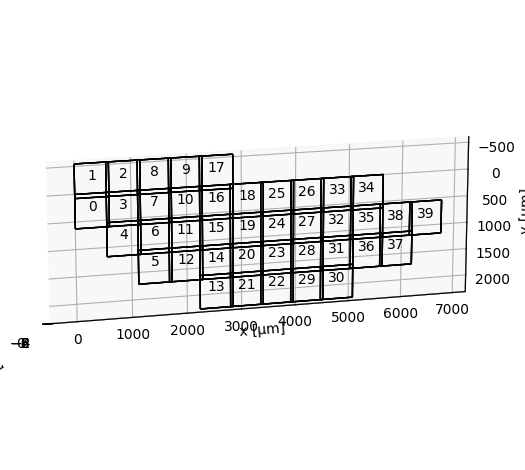

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='z [μm]', ylabel='x [μm]', zlabel='y [μm]'>)

In [7]:
import dask.array as da

tile_shape = (1, 2040, 1992)  # (Z, Y, X)

sims = []

for i in range(len(translations)):
    sim = si_utils.get_sim_from_array(
        da.zeros(tile_shape),
        dims=["z", "y", "x"],
        scale=scale,
        translation=translations[i]
    )
    sims.append(sim)

vis_utils.plot_positions(
    [msi_utils.get_msim_from_sim(sim) for sim in sims],
    use_positional_colors=False,
    transform_key=io.METADATA_TRANSFORM_KEY,
)

In [16]:
from imaris_ims_file_reader.ims import ims
import numpy as np
from pathlib import Path

msims = []
zarr_paths = []

folder = Path(r'Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_2')
ims_files = sorted(folder.glob("*.zarr"))

#zarr_path = r'Z:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_2'
output_folder = Path(r'Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_2')
output_folder.mkdir(parents=True, exist_ok=True)

overwrite = True

for itile, file in enumerate(ims_files):

    zarr_path = output_folder / f"{file.stem}.zarr"

    print(zarr_path)

    # if os.path.exists(zarr_path) and not overwrite:
    #     im_data = da.from_zarr(os.path.join(zarr_path, '0'))[0]
    # else:
    #     ims_file = ims(file)
    #     im_data = ims_file[:]          # (T,C,Z,Y,X)
    #     im_data = np.squeeze(im_data)  # remove T

    #     # ensure correct order
    #     if im_data.ndim == 4:          # (C,Z,Y,X)
    #         im_data = np.moveaxis(im_data, 0, 1)  # → (Z,C,Y,X)

    # sim = si_utils.get_sim_from_array(
    #     im_data,
    #     dims=["z", "c", "y", "x"],
    #     scale=scale,
    #     translation=translations[itile],
    #     transform_key=io.METADATA_TRANSFORM_KEY,
    # )

    #ngff_utils.write_sim_to_ome_zarr(sim, zarr_path, overwrite=overwrite)
    sim = ngff_utils.read_sim_from_ome_zarr(zarr_path)

    msim = msi_utils.get_msim_from_sim(sim)

    zarr_paths.append(zarr_path)
    msims.append(msim)

Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_2\5.2 HIP6 dapi TH DCX 20x_2026-03-25_09.36.31_F00.zarr
Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_2\5.2 HIP6 dapi TH DCX 20x_2026-03-25_09.36.31_F01.zarr
Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_2\5.2 HIP6 dapi TH DCX 20x_2026-03-25_09.36.31_F02.zarr
Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_2\5.2 HIP6 dapi TH DCX 20x_2026-03-25_09.36.31_F03.zarr
Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_2\5.2 HIP6 dapi TH DCX 20x_2026-03-25_09.36.31_F04.zarr
Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_2\5.2 HIP6 dapi TH DCX 20x_2026-03-25_09.36.31_F05.zarr
Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_2\5.2 HIP6 dapi TH DCX 20x_2026-03-25_09.36.31_F06.zarr
Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\full_dataset_zarr_

In [17]:
sim

<xarray.DataArray 'image' (t: 1, c: 3, z: 11, y: 1992, x: 2040)> Size: 268MB
dask.array<from-zarr, shape=(1, 3, 11, 1992, 2040), dtype=uint16, chunksize=(1, 1, 11, 256, 256), chunktype=numpy.ndarray>
Coordinates:
  * t        (t) int64 8B 0
  * c        (c) <U1 12B '0' '1' '2'
  * z        (z) float64 88B -8.6 -7.236 -5.873 -4.509 ... 2.309 3.673 5.036
  * y        (y) float64 16kB 546.1 546.4 546.7 ... 1.152e+03 1.153e+03
  * x        (x) float64 16kB 6.152e+03 6.152e+03 ... 6.772e+03 6.773e+03
Attributes:
    transforms:  {'affine_metadata': <xarray.DataArray (t: 1, x_in: 4, x_out:...

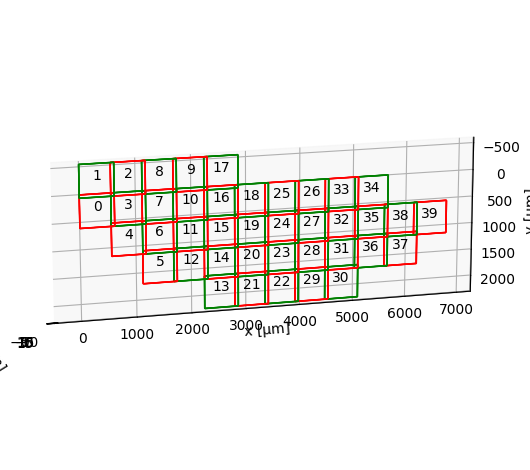

In [18]:
# visualize tile positions/configuration

# uncomment the following line for 3D interactivity with the plot (requires ipympl to be installed)
# % matplotlib widget

from multiview_stitcher import vis_utils

fig, ax = vis_utils.plot_positions(
    msims,
    use_positional_colors=True, # set to False for faster execution in case of more than 20 tiles/views
    transform_key='affine_metadata'
    )

In [19]:
# Turn channel alignment on or off
perform_channel_alignment = False

# Channel alignment is performed using a single tile.
# Choose here which tile (index) to use.
channel_alignment_tile_index = 0

curr_transform_key = 'affine_metadata'
if perform_channel_alignment:
    curr_transform_key = 'affine_metadata_ch_reg'

    channels = msims[channel_alignment_tile_index]['scale0/image'].coords['c']

    # select chosen tiles for registration
    msims_ch_reg = [msi_utils.multiscale_sel_coords(msims[5], {'c': ch})
                    for ch in channels]

    with dask.diagnostics.ProgressBar():
        params_c = registration.register(
            msims_ch_reg,
            registration_binning={'z': 2, 'y': 4, 'x': 4},
            reg_channel_index=0,
            transform_key='affine_metadata',
            pre_registration_pruning_method=None,
        )

    # assign channel coordinates to obtained parameters
    params_c = xr.concat(params_c, dim='c').assign_coords({'c': channels})

    # set obtained parameters for all tiles
    for msim in msims:
        msi_utils.set_affine_transform(
            msim, params_c, transform_key=curr_transform_key, base_transform_key='affine_metadata')


In [20]:
with dask.diagnostics.ProgressBar():

    params = registration.register(
        msims,
        registration_binning={'z': 1, 'y': 3, 'x': 3},
        reg_channel_index=0,
        transform_key=curr_transform_key,
        new_transform_key='affine_registered',
        pre_registration_pruning_method="keep_axis_aligned", # works well for tiles on a grid
    )

[########################################] | 100% Completed | 8.50 ss
[########################################] | 100% Completed | 4.57 ss
[########################################] | 100% Completed | 4.47 sms
[########################################] | 100% Completed | 4.17 sms
[########################################] | 100% Completed | 4.38 sms
[########################################] | 100% Completed | 4.58 sms
[########################################] | 100% Completed | 4.68 sms
[########################################] | 100% Completed | 4.27 sms
[########################################] | 100% Completed | 4.38 sms
[########################################] | 100% Completed | 4.37 sms
[########################################] | 100% Completed | 4.07 sms
[########################################] | 100% Completed | 3.56 sms
[########################################] | 100% Completed | 6.41 sms
[########################################] | 100% Completed | 5.62 sms
[#######

In [21]:
for imsim, msim in enumerate(msims):
    affine = np.array(msi_utils.get_transform_from_msim(msim, transform_key='affine_registered')[0])
    print(f'tile index {imsim}\n', affine)

tile index 0
 [[ 1.          0.          0.          0.22959877]
 [ 0.          1.          0.          0.44307304]
 [ 0.          0.          1.         11.76505521]
 [ 0.          0.          0.          1.        ]]
tile index 1
 [[ 1.          0.          0.          0.45919497]
 [ 0.          1.          0.         12.76526839]
 [ 0.          0.          1.         11.65087235]
 [ 0.          0.          0.          1.        ]]
tile index 2
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00  6.97297355e-03]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  1.27514311e+01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00 -3.42453109e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
tile index 3
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
tile index 4
 [[  1.           0.           0.          -0.16393651]
 [  0.           1.           0.         -13.36142335]
 [  0.           0.           1.           0.38213727]
 [  0.           0.      

In [ ]:
import importlib
importlib.reload(fusion)
importlib.reload(ngff_utils)



fused = fusion.fuse(
    [msi_utils.get_sim_from_msim(msim) for msim in msims],
    transform_key='affine_registered',
    #output_shape={dim: 30 for dim in ['x', 'y', 'z']},
    output_chunksize=512,
    )



In [39]:
fused = fused.chunk({
    "z": 20,
    "c": 3,
    "y": 2048,
    "x": 2048
})

fused = fused.astype("uint16")

In [40]:
output_dir = Path(r'Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\fused_output')
output_dir.mkdir(parents=True, exist_ok=True)
output_filename = os.path.join(output_dir, 'fused.zarr')

print(f'Fusing views and saving output to {output_filename}...')
fused = ngff_utils.write_sim_to_ome_zarr(
    fused, output_filename, overwrite=True, show_progressbar=True
)


Fusing views and saving output to Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\fused_output\fused.zarr...
Removing existing Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\fused_output\fused.zarr...
Writing resolution level 0...


c:\Users\simao\anaconda3\envs\multiviewstitcher_env\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'config'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
  2%|▏         | 1/55 [01:07<1:00:35, 67.33s/it]c:\Users\simao\anaconda3\envs\multiviewstitcher_env\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'config'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
  4%|▎         | 2/55 [01:58<50:56, 57.67s/it]  c:\Users\simao\anaconda3\envs\multiviewstitcher_env\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'config'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
  5%|▌         | 3/55 [02:52<48:26, 55.89s/it]c:\Users\simao\anaconda3\envs\multiviewstitcher_env\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'config'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
  

Writing resolution level 1...


100%|██████████| 18/18 [04:38<00:00, 15.48s/it]


Writing resolution level 2...


...

100%|██████████| 1/1 [00:02<00:00,  2.13s/it]


Writing resolution level 6...


100%|██████████| 1/1 [00:01<00:00,  1.77s/it]


Writing resolution level 7...


100%|██████████| 1/1 [00:01<00:00,  1.49s/it]


In [35]:
import tifffile
import numpy as np
from dask.diagnostics import ProgressBar

output_dir = Path(r'Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\fused_output')
output_dir.mkdir(parents=True, exist_ok=True)
output_filename = os.path.join(output_dir, 'fused.tif')

with tifffile.TiffWriter(output_filename, bigtiff=True) as tif:
    with ProgressBar():
        for block in fused.data.to_delayed().ravel():
            chunk = block.compute()
            tif.write(chunk)

[########################################] | 100% Completed | 1.95 sms
[########################################] | 100% Completed | 1.73 sms
[########################################] | 100% Completed | 1.54 sms
[########################################] | 100% Completed | 2.35 sms
[########################################] | 100% Completed | 1.84 sms
[########################################] | 100% Completed | 2.04 sms
[########################################] | 100% Completed | 1.64 sms
[####################################    ] | 91% Completed | 1.32 s ms


KeyboardInterrupt: 

In [29]:
import tifffile as tiff

img = tiff.imread(r"Y:\2. GOUACHE\9. Software Solutions\4. Multiview stitcher\fused_output\fused4.tif")

print(type(img))
print(img.shape)
print(img.dtype)

<class 'numpy.ndarray'>
(1, 3, 9003, 21772)
uint16


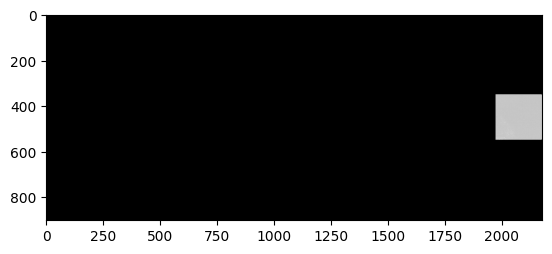

In [31]:
import matplotlib.pyplot as plt

slice_ = img[0, 0, ::10, ::10]

slice_8 = (slice_ / slice_.max() * 255).astype("uint8")

plt.imshow(slice_8, cmap="gray")
plt.show()